<a href="https://colab.research.google.com/github/sraymundo15/sraymundo15/blob/master/Calorimetry%20Lab/CHM343_Physical_Chemistry_Lab_2_Colab_Notebook_Sebastian_Raymundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ASU CHM 343 Physical Chemistry Lab '2' - Notebook**

***Determination of Thermochemical Properties of Fatty Acids and Sugars by Using Simulated Bomb Calorimetry Data***

September 23, 2025

**Sebastian Raymundo**, sraymun1@asu.edu

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CHM343/Calorimetry/blob/main/Notebooks/Bomb_Cal_Simulation_Example_CHM343_Spring2025.ipynb)


# **Abstract**

# **Introduction**

# **Methods**

# **Setup Notebook Environment**

In [29]:
# Primary Python Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Data/Results**

---



This is simulation data obtained using the Calorimeter Code 3655 and uploaded to my public GitHub repo.

In [30]:
# Read in Bomb Cal Simulated Data

df_BenzoicAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_benzoic_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_Naphthalene_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_naphthalene_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_LauricAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_lauric_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_b_d_Fructose_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_%CE%B2-d-fructose_cc3655.csv', sep = "," , header=11, skiprows=[11])

# Plotting and Analysis of Each Substance for Calorimeter Code 3655

Substances selected: Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose

# Benzoic Acid

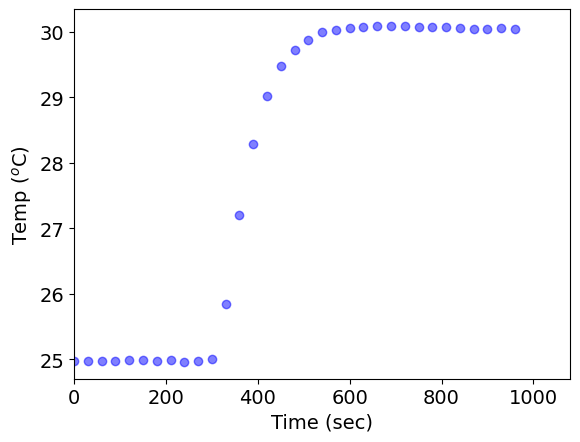

In [31]:
#@title Plot for Benzoic Acid
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1080)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

In [32]:
#@title Determine ΔT
# Linear Extrapolation of starting and ending
Number_Points = 10
Bomb_Cal_Initial = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.start:df_BenzoicAcid_3655.index.start+Number_Points]
Bomb_Cal_Final = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.stop-1-Number_Points:df_BenzoicAcid_3655.index.stop-1]

# Linear fits for initial and final data points
mi, bi = np.polyfit(Bomb_Cal_Initial['Time (s)'], Bomb_Cal_Initial['Temperature (C)'], deg=1)
mf, bf = np.polyfit(Bomb_Cal_Final['Time (s)'], Bomb_Cal_Final['Temperature (C)'], deg=1)

# Estimate Delta T from linear extrapolations
guess_temp = 375
dt = ((bf + mf * guess_temp) - (bi + mi * guess_temp))

# Estimate Delta T from max/min (good estimate if water temp is > room temp)
dt_est = df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500
dt_min = ((bf + mf * guess_tmin) - (bi + mi * guess_tmin))
dt_max = ((bf + mf * guess_tmax) - (bi + mi * guess_tmax))

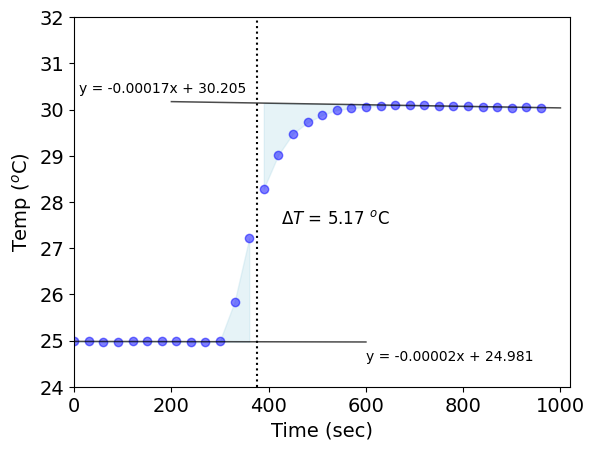

In [33]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines
ax.plot(xseq_initial, bi + mi * xseq_initial, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq_final, bf + mf * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change
ax.axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations
ax.fill_between(df_BenzoicAcid_3655['Time (s)'],bi + mi * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

ax.fill_between(df_BenzoicAcid_3655['Time (s)'],bf + mf * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)


# Annotate ΔT
ax.text(guess_temp+50, (df_BenzoicAcid_3655['Temperature (C)'].min() + (df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt, 2)), fontsize=12)

# Annotate regression lines with equations
ax.annotate(f'y = {mi:.5f}x + {bi:.3f}', xy=(xseq_initial[-1], bi + mi * xseq_initial[-1]), xytext=(600, bi + mi * xseq_initial[-1] - 0.4),fontsize=10)

ax.annotate(f'y = {mf:.5f}x + {bf:.3f}', xy=(xseq_final[0], bf + mf * xseq_final[0]), xytext=(10, bf + mf * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1020)
plt.ylim(24, 32)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

The calorimeter constant ($C$<sub>eq</sub>) was calculated as follows:

\begin{equation}
{C}_{eq} = \frac{{E}_{released}}{-\Delta T} =
\end{equation}

 where $E$<sub>released</sub> = $C$<sub>sample</sub> X (sample weight) + $C$<sub>wire</sub> X (wire weight).

 The calorimeter constant table lists the value at 10042.50 J/K (for #0001).  The instructions are confusing with respect to if the Ceq is positive or negative.


In [34]:
#@title Calculate Calorimeter Constant
Hba = 26425
Hfe = 5858
Wba = 1.9730
Wfe = 0.024-0.018
Erel = (Hba*Wba)+(Hfe*Wfe)
Ceq = Erel/dt

print('Ceq =', round(Ceq,2))

Ceq = 10094.9


In [35]:
#@title Horizontal Line Thermodynamic Estimate (Over-Estimate)
Ceq = Erel/dt_est
print('Ceq =', round(Ceq,2))

Ceq = 10169.92


In [36]:
#@title Thermodynamic Estimate - Minimum and Maximum
Ceq_min = Erel/dt_min
Ceq_max = Erel/dt_max

print('Ceq,min =', round(Ceq_min,2), " ", 'Ceq,max =', round(Ceq_max,2))

Ceq,min = 10073.05   Ceq,max = 10131.53


# Naphthalene

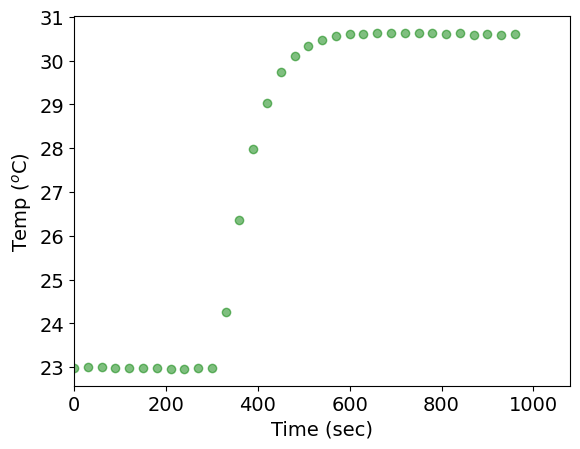

In [37]:
#@title Plot for Naphthalene
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1080)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

In [38]:
#@title Determine ΔT
# Linear Extrapolation of starting and ending
Number_Points = 10
Bomb_Cal_Initial = df_Naphthalene_3655[df_Naphthalene_3655.index.start:df_Naphthalene_3655.index.start+Number_Points]
Bomb_Cal_Final = df_Naphthalene_3655[df_Naphthalene_3655.index.stop-1-Number_Points:df_Naphthalene_3655.index.stop-1]

# Linear fits for initial and final data points
mi, bi = np.polyfit(Bomb_Cal_Initial['Time (s)'], Bomb_Cal_Initial['Temperature (C)'], deg=1)
mf, bf = np.polyfit(Bomb_Cal_Final['Time (s)'], Bomb_Cal_Final['Temperature (C)'], deg=1)

# Estimate Delta T from linear extrapolations
guess_temp = 375
dt = ((bf + mf * guess_temp) - (bi + mi * guess_temp))

# Estimate Delta T from max/min (good estimate if water temp is > room temp)
dt_est = df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500
dt_min = ((bf + mf * guess_tmin) - (bi + mi * guess_tmin))
dt_max = ((bf + mf * guess_tmax) - (bi + mi * guess_tmax))

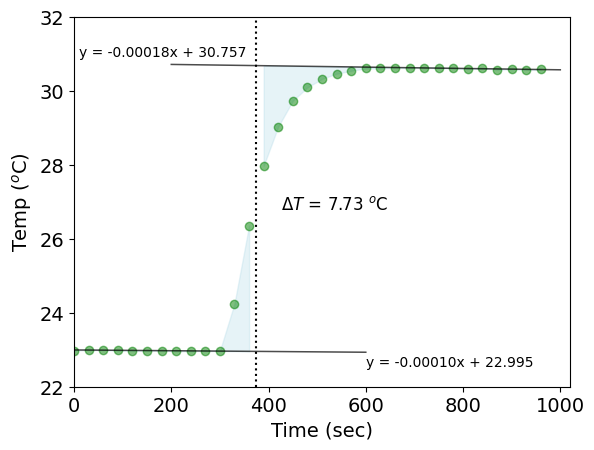

In [39]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines
ax.plot(xseq_initial, bi + mi * xseq_initial, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq_final, bf + mf * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change
ax.axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations
ax.fill_between(df_Naphthalene_3655['Time (s)'],bi + mi * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

ax.fill_between(df_Naphthalene_3655['Time (s)'],bf + mf * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)


# Annotate ΔT
ax.text(guess_temp+50, (df_Naphthalene_3655['Temperature (C)'].min() + (df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt, 2)), fontsize=12)

# Annotate regression lines with equations
ax.annotate(f'y = {mi:.5f}x + {bi:.3f}', xy=(xseq_initial[-1], bi + mi * xseq_initial[-1]), xytext=(600, bi + mi * xseq_initial[-1] - 0.4),fontsize=10)

ax.annotate(f'y = {mf:.5f}x + {bf:.3f}', xy=(xseq_final[0], bf + mf * xseq_final[0]), xytext=(10, bf + mf * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1020)
plt.ylim(22, 32)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.

# Lauric Acid

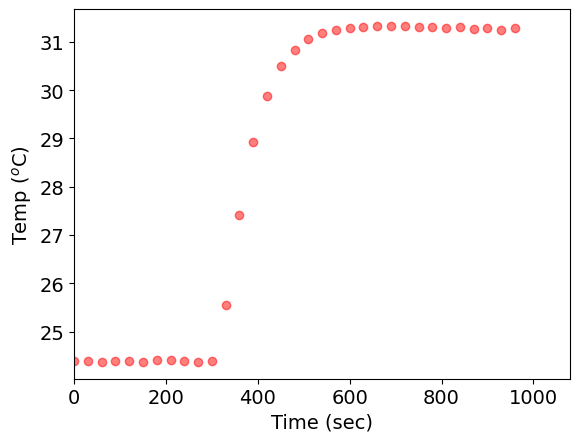

In [40]:
#@title Plot for Lauric Acid
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Lauric Acid')

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1080)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

In [41]:
#@title Determine ΔT
# Linear Extrapolation of starting and ending
Number_Points = 10
Bomb_Cal_Initial = df_LauricAcid_3655[df_LauricAcid_3655.index.start:df_LauricAcid_3655.index.start+Number_Points]
Bomb_Cal_Final = df_LauricAcid_3655[df_LauricAcid_3655.index.stop-1-Number_Points:df_LauricAcid_3655.index.stop-1]

# Linear fits for initial and final data points
mi, bi = np.polyfit(Bomb_Cal_Initial['Time (s)'], Bomb_Cal_Initial['Temperature (C)'], deg=1)
mf, bf = np.polyfit(Bomb_Cal_Final['Time (s)'], Bomb_Cal_Final['Temperature (C)'], deg=1)

# Estimate Delta T from linear extrapolations
guess_temp = 375
dt = ((bf + mf * guess_temp) - (bi + mi * guess_temp))

# Estimate Delta T from max/min (good estimate if water temp is > room temp)
dt_est = df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500
dt_min = ((bf + mf * guess_tmin) - (bi + mi * guess_tmin))
dt_max = ((bf + mf * guess_tmax) - (bi + mi * guess_tmax))

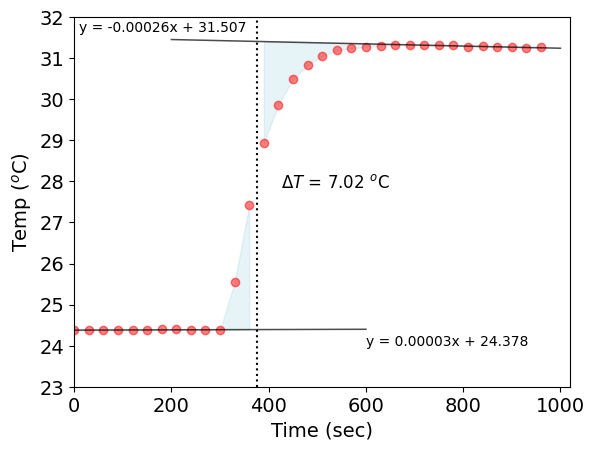

In [42]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Naphthalene')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines
ax.plot(xseq_initial, bi + mi * xseq_initial, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq_final, bf + mf * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change
ax.axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations
ax.fill_between(df_LauricAcid_3655['Time (s)'],bi + mi * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

ax.fill_between(df_LauricAcid_3655['Time (s)'],bf + mf * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)


# Annotate ΔT
ax.text(guess_temp+50, (df_LauricAcid_3655['Temperature (C)'].min() + (df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt, 2)), fontsize=12)

# Annotate regression lines with equations
ax.annotate(f'y = {mi:.5f}x + {bi:.3f}', xy=(xseq_initial[-1], bi + mi * xseq_initial[-1]), xytext=(600, bi + mi * xseq_initial[-1] - 0.4),fontsize=10)

ax.annotate(f'y = {mf:.5f}x + {bf:.3f}', xy=(xseq_final[0], bf + mf * xseq_final[0]), xytext=(10, bf + mf * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1020)
plt.ylim(23, 32)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.

# β-d-Fructose

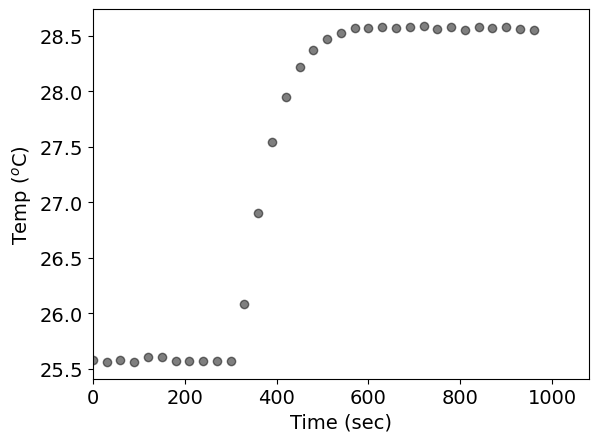

In [43]:
#@title Plot for β-d-Fructose
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1080)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

In [44]:
#@title Determine ΔT
# Linear Extrapolation of starting and ending
Number_Points = 10
Bomb_Cal_Initial = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.start:df_b_d_Fructose_3655.index.start+Number_Points]
Bomb_Cal_Final = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.stop-1-Number_Points:df_b_d_Fructose_3655.index.stop-1]

# Linear fits for initial and final data points
mi, bi = np.polyfit(Bomb_Cal_Initial['Time (s)'], Bomb_Cal_Initial['Temperature (C)'], deg=1)
mf, bf = np.polyfit(Bomb_Cal_Final['Time (s)'], Bomb_Cal_Final['Temperature (C)'], deg=1)

# Estimate Delta T from linear extrapolations
guess_temp = 375
dt = ((bf + mf * guess_temp) - (bi + mi * guess_temp))

# Estimate Delta T from max/min (good estimate if water temp is > room temp)
dt_est = df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500
dt_min = ((bf + mf * guess_tmin) - (bi + mi * guess_tmin))
dt_max = ((bf + mf * guess_tmax) - (bi + mi * guess_tmax))

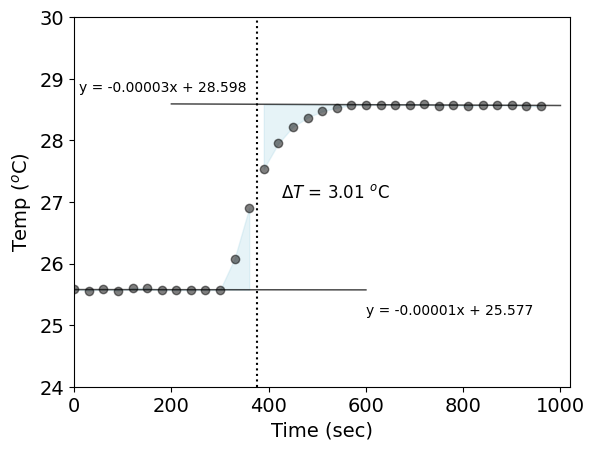

In [45]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
ax.plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines
ax.plot(xseq_initial, bi + mi * xseq_initial, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq_final, bf + mf * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change
ax.axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations
ax.fill_between(df_b_d_Fructose_3655['Time (s)'],bi + mi * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

ax.fill_between(df_b_d_Fructose_3655['Time (s)'],bf + mf * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)


# Annotate ΔT
ax.text(guess_temp+50, (df_b_d_Fructose_3655['Temperature (C)'].min() + (df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt, 2)), fontsize=12)

# Annotate regression lines with equations
ax.annotate(f'y = {mi:.5f}x + {bi:.3f}', xy=(xseq_initial[-1], bi + mi * xseq_initial[-1]), xytext=(600, bi + mi * xseq_initial[-1] - 0.4),fontsize=10)

ax.annotate(f'y = {mf:.5f}x + {bf:.3f}', xy=(xseq_final[0], bf + mf * xseq_final[0]), xytext=(10, bf + mf * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot
plt.xlim(0, 1020)
plt.ylim(24, 30)
plt.xlabel("Time (sec)", fontsize=14)
plt.ylabel("Temp ($^o$C)", fontsize=14)

# Display the Plot
plt.show()

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.